# Function Plotting
This file is designed to allow me to plot functions so that I can visually check stationary points for functions of 2 variables that are difficult/impossible to plot by hand. The code was taken from the page located [here](https://www.sfu.ca/~jtmulhol/py4math/matplotlib/04-multivariable/) from Simon Fraser University.

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp

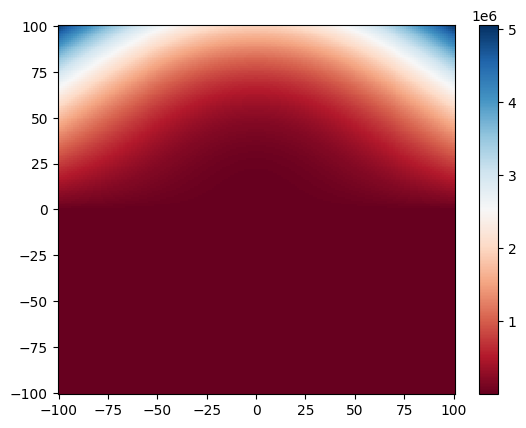

In [7]:
def f(x,y):
    return 2*y**3 - 6*y**2 + 3*x**2*y

x = np.linspace(-100,100,200)
y = np.linspace(-100,100,200)
X, Y = np.meshgrid(x,y)
Z = f(X,Y)

fig, ax = plt.subplots()

p = ax.pcolor(X, Y, Z, cmap=plt.cm.RdBu,
    
vmin=abs(Z).min(), vmax=abs(Z).max())
cb = fig.colorbar(p, ax=ax)

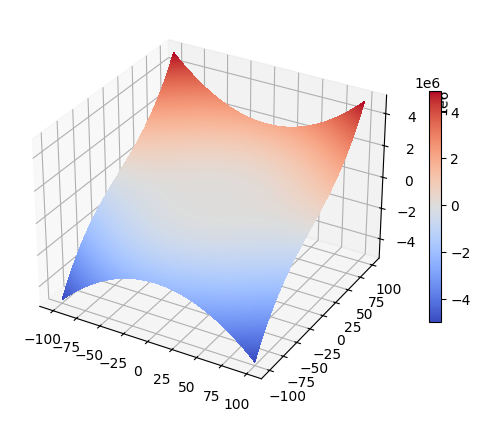

In [8]:
fig = plt.figure(figsize=(14,6))

# surface_plot with color grading and color bar
ax = fig.add_subplot(1, 2, 2, projection='3d')
p = ax.plot_surface(X, Y, Z, rstride=1, cstride=1,
    
cmap=plt.cm.coolwarm, linewidth=0, antialiased=False)
cb = fig.colorbar(p, shrink=0.5)

AI produced code to find stationary points and classify them

In [10]:
x, y = sp.symbols('x y')
f = x**4 + 2*x**2*y + y**2 - 4*x**2 - 8*x - 8*y

# 1. Compute first partial derivatives (Gradient)
df_dx = sp.diff(f, x)
df_dy = sp.diff(f, y)

# 2. Find critical points where derivatives equal zero
critical_points = sp.solve([df_dx, df_dy], (x, y))
print("Critical Points:", critical_points)

# 3. Compute second partial derivatives (Hessian matrix)
f_xx = sp.diff(df_dx, x)
f_xy = sp.diff(df_dx, y)
f_yy = sp.diff(df_dy, y)

Hessian = sp.Matrix([[f_xx, f_xy], [f_xy, f_yy]])

# 4. Analyze each critical point using eigenvalues
for pt in critical_points:
  # Substitute point into Hessian
  H_eval = Hessian.subs({x: pt[0], y: pt[1]})
  H_num = np.array(H_eval).astype(np.float64)

  # Find eigenvalues
  eigenvals = np.linalg.eigvalsh(H_num)

  # Determine nature
  if all(eigenvals > 0):
    nature = 'Local Minimum'
  elif all(eigenvals < 0):
    nature = 'Local Maximum'
  elif any(eigenvals > 0) and any(eigenvals < 0):
    nature = 'Saddle Point'
  else:
    nature = 'Inconclusive'

  print(f'Point {pt}: {nature} (Eigenvalues: {eigenvals})')

Critical Points: [(1, 3)]
Point (1, 3): Local Minimum (Eigenvalues: [ 0.93774225 17.06225775])
